In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict, Any
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os

In [2]:
load_dotenv()
model = ChatGroq(model="llama-3.3-70b-versatile", 
                 api_key=os.getenv("API_KEY"),
                 temperature=0.1)

In [3]:
class CricketMetrics(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int
    sr: float
    bpb: float
    boundary_percentage: float
    summary: str

In [4]:
def strike_rate_node(state: CricketMetrics) -> CricketMetrics:
    if state["balls"] == 0:
        return {"sr": 0.0}
    return {"sr": (state["runs"] / state["balls"]) * 100}

In [5]:
def balls_per_boundary_node(state: CricketMetrics) -> CricketMetrics:
    total_boundaries = state["fours"] + state["sixes"]
    if total_boundaries == 0:
        return {"bpb": 0.0}  # Avoid division by zero
    else:
        return {"bpb": state["balls"] / total_boundaries}

In [6]:
def boundary_percentage_node(state: CricketMetrics) -> CricketMetrics:
    total_boundaries = state["fours"] + state["sixes"]
    if state["balls"] == 0:
        return {"boundary_percentage": 0.0}
    else:
        return {"boundary_percentage": (total_boundaries / state["balls"]) * 100}

In [12]:
def summary_node(state: CricketMetrics) -> CricketMetrics:
    prompt = f"""
    Given the following cricket metrics:
    - Runs: {state['runs']}
    - Balls: {state['balls']}
    - Fours: {state['fours']}
    - Sixes: {state['sixes']}
    - Strike Rate: {state['sr']:.2f}
    - Balls per Boundary: {state['bpb']:.2f}
    - Boundary Percentage: {state['boundary_percentage']:.2f}%

    Provide a brief summary of the player's performance.
    """
    response = model.invoke(prompt)
    return {"summary": response.content}

In [13]:
graph = StateGraph(CricketMetrics)

graph.add_node("strike_rate_node",strike_rate_node)
graph.add_node("balls_per_boundary_node",balls_per_boundary_node)
graph.add_node("boundary_percentage_node",boundary_percentage_node)
graph.add_node("summary_node",summary_node)

graph.add_edge(START,"strike_rate_node")
graph.add_edge(START,"balls_per_boundary_node")
graph.add_edge(START,"boundary_percentage_node")
graph.add_edge("strike_rate_node","summary_node")
graph.add_edge("balls_per_boundary_node","summary_node")
graph.add_edge("boundary_percentage_node","summary_node")
graph.add_edge("summary_node",END)

workflow=graph.compile()
result=workflow.invoke({"runs": 50, "balls": 30, "fours": 4, "sixes": 2})

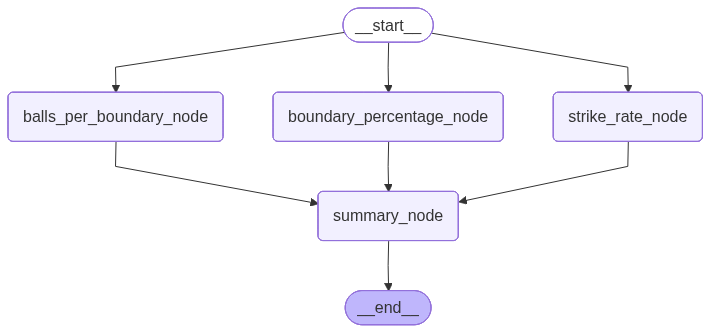

In [14]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [15]:
print(result)

{'runs': 50, 'balls': 30, 'fours': 4, 'sixes': 2, 'sr': 166.66666666666669, 'bpb': 5.0, 'boundary_percentage': 20.0, 'summary': "Based on the provided cricket metrics, the player had an exceptional performance. \n\nThey scored 50 runs off just 30 balls, achieving a high strike rate of 166.67, indicating an aggressive batting approach. The player hit 4 fours and 2 sixes, with a boundary percentage of 20%, showing their ability to score quickly and find the boundaries. \n\nThe balls per boundary metric of 5.00 suggests that the player was able to hit a boundary every 5 balls on average, further highlighting their impressive performance. Overall, the player's statistics indicate a dominant and explosive batting display."}


In [ ]:
result['sr']

166.66666666666669

In [ ]:
result['boundary_percentage']

20.0

In [ ]:
result['bpb']

5.0

In [17]:
result['summary']

"Based on the provided cricket metrics, the player had an exceptional performance. \n\nThey scored 50 runs off just 30 balls, achieving a high strike rate of 166.67, indicating an aggressive batting approach. The player hit 4 fours and 2 sixes, with a boundary percentage of 20%, showing their ability to score quickly and find the boundaries. \n\nThe balls per boundary metric of 5.00 suggests that the player was able to hit a boundary every 5 balls on average, further highlighting their impressive performance. Overall, the player's statistics indicate a dominant and explosive batting display."